# 모의고사 7회 | 고객 이탈 예측

> **AICE Associate 실전 연습용**
>
> 필요한 라이브러리와 함수는 직접 판단하여 사용하세요.  
> 각 문제의 변수명과 조건은 특별한 지시가 없는 한 그대로 유지하세요.

## 데이터셋
- `customer_data.json`: 고객 기본 정보
- `call_history.csv`: 고객 통화 이력

## 컬럼 정보

### customer_data.json
- `CustomerID`: 고객 고유 ID
- `SubscriptionType`: 구독 종류 (`Basic`, `Standard`, `Premium`)
- `MonthlyCharges_USD`: 월 요금 (USD)
- `TotalUsage_GB`: 총 사용량 (GB)
- `ContractDuration_Months`: 계약 기간 (개월)
- `ServiceRegion`: 서비스 지역 (`RegionA`, `RegionB`, `RegionC`)
- `IsNewCustomer`: 신규 고객 여부 (`True`, `False`)
- `Churn`: 이탈 여부 (`0`: 이탈하지 않음, `1`: 이탈) — 예측 대상 변수

### call_history.csv
- `CustomerID`: 고객 고유 ID
- `CallCenterInteractions`: 콜센터 상호작용 횟수
- `ComplaintCount`: 불만 제기 횟수
- `TechSupportTickets`: 기술 지원 티켓 수
- `PaymentIssues`: 결제 문제 발생 여부 (`0`: 없음, `1`: 있음)


## 7-1 | 데이터 로딩

### 문제
두 개의 데이터 파일을 읽어 데이터프레임으로 저장하세요.

- `customer_data.json` → `df_customer`
- `call_history.csv` → `df_call`
- 필요한 라이브러리는 직접 임포트하세요.

In [260]:
# 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [261]:
# 데이터 불러오기
df_customer = pd.read_json('C:/juehyeon/aice_test/기출문제/7.고객이탈예측/customer_data.json')
df_call = pd.read_csv('C:/juehyeon/aice_test/기출문제/7.고객이탈예측/call_history.csv')

In [262]:
# 데이터 확인하기
df_customer.info() #결측치 확인 TotalUsage : 30개 , 범주형 변수 Customer ID, SubscriptionType, ServiceRegion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               600 non-null    object 
 1   SubscriptionType         600 non-null    object 
 2   MonthlyCharges_USD       600 non-null    float64
 3   TotalUsage_GB            570 non-null    float64
 4   ContractDuration_Months  600 non-null    int64  
 5   ServiceRegion            600 non-null    object 
 6   IsNewCustomer            600 non-null    bool   
 7   Churn                    600 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 33.5+ KB


In [263]:
# 데이터 확인하기
df_call.info() #결측치 X

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              600 non-null    object
 1   CallCenterInteractions  600 non-null    int64 
 2   ComplaintCount          600 non-null    int64 
 3   TechSupportTickets      600 non-null    int64 
 4   PaymentIssues           600 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 23.6+ KB


## 7-2 | 데이터 병합

### 문제
두 데이터프레임을 `CustomerID`를 기준으로 병합하세요.

- `df_customer`의 모든 행이 유지되어야 합니다.
- 병합 결과는 `df` 변수에 저장하세요.

In [264]:
# 데이터 병합
df = pd.merge(df_customer, df_call, on = 'CustomerID', how = 'left')

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               600 non-null    object 
 1   SubscriptionType         600 non-null    object 
 2   MonthlyCharges_USD       600 non-null    float64
 3   TotalUsage_GB            570 non-null    float64
 4   ContractDuration_Months  600 non-null    int64  
 5   ServiceRegion            600 non-null    object 
 6   IsNewCustomer            600 non-null    bool   
 7   Churn                    600 non-null    int64  
 8   CallCenterInteractions   600 non-null    int64  
 9   ComplaintCount           600 non-null    int64  
 10  TechSupportTickets       600 non-null    int64  
 11  PaymentIssues            600 non-null    int64  
dtypes: bool(1), float64(2), int64(6), object(3)
memory usage: 52.3+ KB


## 7-3 | 불필요한 컬럼 삭제

### 문제
모델링에 사용하지 않을 `CustomerID` 컬럼을 `df`에서 삭제하세요.

In [266]:
# 컬럼 삭제
df = df.drop(columns = 'CustomerID')

In [267]:
# 컬럼 확인
df.columns

Index(['SubscriptionType', 'MonthlyCharges_USD', 'TotalUsage_GB',
       'ContractDuration_Months', 'ServiceRegion', 'IsNewCustomer', 'Churn',
       'CallCenterInteractions', 'ComplaintCount', 'TechSupportTickets',
       'PaymentIssues'],
      dtype='object')

## 7-4 | 결측치 처리

### 문제
`TotalUsage_GB` 컬럼의 결측치를 해당 컬럼의 **최빈값**으로 대체하세요.

처리 후 실제로 결측치가 남아 있지 않은지도 확인하세요.

In [268]:
# 결측치 확인
df['TotalUsage_GB'].isna().sum()

np.int64(30)

In [269]:
# 최빈값 확인
mode_tu = df['TotalUsage_GB'].mode()[0]
print(mode_tu)

16.0


In [270]:
# 결측치 대체 
df['TotalUsage_GB'] = df['TotalUsage_GB'].fillna(mode_tu)

In [271]:
# 결측치 대체 확인
df.isna().sum()

SubscriptionType           0
MonthlyCharges_USD         0
TotalUsage_GB              0
ContractDuration_Months    0
ServiceRegion              0
IsNewCustomer              0
Churn                      0
CallCenterInteractions     0
ComplaintCount             0
TechSupportTickets         0
PaymentIssues              0
dtype: int64

## 7-5 | 범주형 변수 분포 시각화

### 문제
`SubscriptionType`과 `ServiceRegion`의 값 분포를 각각 막대 그래프로 시각화하세요.

- 두 컬럼의 범주별 빈도를 확인할 수 있어야 합니다.
- 그래프만 보고 특정 범주에 데이터가 과도하게 몰려 있는지 판단할 수 있도록 작성하세요.

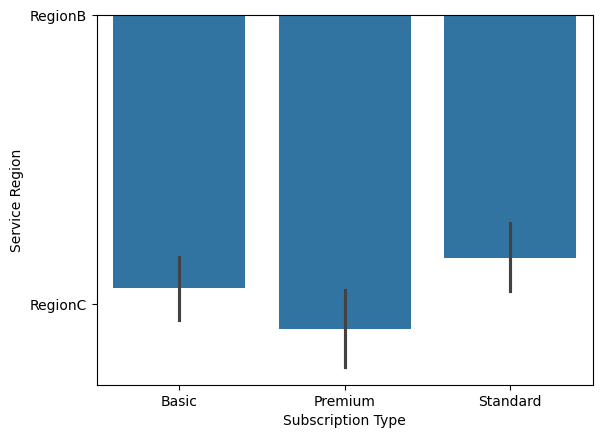

In [272]:
# 데이터 시각화
cols = ['SubscriptionType', 'ServiceRegion']
sns.barplot(data = df, x = 'SubscriptionType', y = 'ServiceRegion')
plt.xlabel('Subscription Type')
plt.ylabel('Service Region')
plt.show()

## 7-6 | 이진 범주형 변수 변환

### 문제
`IsNewCustomer` 컬럼을 다음과 같이 정수형 값으로 변환하세요.

- `True` → `1`
- `False` → `0`

변환 후 컬럼의 데이터 타입도 확인하세요.

In [273]:
# 데이터 확인
df['IsNewCustomer'].values

array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True, False, False, False, False, False,
        True, False, False, False,  True, False, False, False, False,
       False,  True, False, False, False, False, False,  True, False,
       False, False,  True, False, False, False, False, False, False,
        True, False, False, False, False,  True,  True, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False,  True, False, False,  True,  True,
       False, False,  True, False,  True, False, False, False, False,
       False, False,

In [274]:
# 데이터 타입 확인
df['IsNewCustomer'].dtype

dtype('bool')

In [275]:
# 데이터 변환
df['IsNewCustomer'] = df['IsNewCustomer'].map({True: 0, False: 1})

In [276]:
df.head()

,SubscriptionType,MonthlyCharges_USD,TotalUsage_GB,ContractDuration_Months,ServiceRegion,IsNewCustomer,Churn,CallCenterInteractions,ComplaintCount,TechSupportTickets,PaymentIssues
0,Basic,41.96,385.0,12,RegionB,1,0,6,7,7,1
1,Premium,56.22,464.0,24,RegionB,1,0,3,6,1,0
2,Standard,43.01,11.0,6,RegionC,1,0,12,4,9,1
3,Standard,31.53,33.0,24,RegionA,1,0,14,5,7,1
4,Basic,35.68,399.0,1,RegionC,1,1,10,4,2,1


In [277]:
# 데이터 타입 확인 
df['IsNewCustomer'].dtype

dtype('int64')

## 7-7 | 범주형 변수 원-핫 인코딩

### 문제
`SubscriptionType`과 `ServiceRegion`을 원-핫 인코딩하세요.

- 나머지 컬럼은 유지하세요.
- 결과는 `df_encoded` 변수에 저장하세요.
- 인코딩 후 두 원본 범주형 컬럼이 그대로 남아 있지 않도록 하세요.

In [278]:
# 원-핫 인코딩
incod_cols = ['SubscriptionType', 'ServiceRegion']
df = pd.get_dummies(data = df, columns = incod_cols)

In [279]:
# 인코딩 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MonthlyCharges_USD         600 non-null    float64
 1   TotalUsage_GB              600 non-null    float64
 2   ContractDuration_Months    600 non-null    int64  
 3   IsNewCustomer              600 non-null    int64  
 4   Churn                      600 non-null    int64  
 5   CallCenterInteractions     600 non-null    int64  
 6   ComplaintCount             600 non-null    int64  
 7   TechSupportTickets         600 non-null    int64  
 8   PaymentIssues              600 non-null    int64  
 9   SubscriptionType_Basic     600 non-null    bool   
 10  SubscriptionType_Premium   600 non-null    bool   
 11  SubscriptionType_Standard  600 non-null    bool   
 12  ServiceRegion_RegionA      600 non-null    bool   
 13  ServiceRegion_RegionB      600 non-null    bool   

In [280]:
# 변수 재할당
df_encoded = df.copy()

## 7-8 | 데이터 분리 및 스케일링

### 문제
`Churn`을 예측하기 위한 학습 데이터를 준비하세요.

- `Churn` → `y`
- 나머지 컬럼 → `X`
- 훈련 데이터 80%, 검증 데이터 20%로 분할하세요.
- `random_state=42`를 사용하세요.
- 훈련 데이터의 특성을 기준으로 표준화 기준을 학습하세요.
- 훈련 데이터와 검증 데이터를 각각 변환하여 `X_train_scaled`, `X_valid_scaled`에 저장하세요.

⚠️ 검증 데이터로 표준화 기준을 다시 학습하면 안 됩니다.

In [281]:
# 피처, 타겟 데이터 분리
X = df_encoded.drop(columns ='Churn')
y = df_encoded['Churn']

In [282]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [283]:
# 훈련, 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [284]:
# 데이터 스케일링
from sklearn.preprocessing import StandardScaler

In [285]:
# 스케일링 객체 생성
scaler = StandardScaler()

In [286]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## 7-9 | Logistic Regression 모델 학습

### 문제
고객 이탈 여부를 예측하는 Logistic Regression 분류 모델을 생성하고 학습하세요.

- `random_state=42`
- 모델 변수명: `logreg_model`
- 앞 단계에서 Logistic Regression 학습에 적절하게 준비한 훈련 데이터를 사용하세요.

In [287]:
# 라이브러리 임포트
from sklearn.linear_model import LogisticRegression

In [288]:
# 모델 객체 생성
logreg_model = LogisticRegression(random_state = 42)

In [289]:
# 데이터 학습
logreg_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 7-10 | Decision Tree 모델 학습

### 문제
Decision Tree 분류 모델을 생성하고 학습하세요.

- `max_depth=5`
- `random_state=42`
- 모델 변수명: `dt_model`
- 스케일링 전의 훈련 데이터를 사용하세요.

In [290]:
# 라이브러리 임포트
from sklearn.tree import DecisionTreeClassifier

In [291]:
# 모델 생성
dt_model = DecisionTreeClassifier(random_state = 42, max_depth = 5)

In [292]:
# 모델 학습
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## 7-11 | 딥러닝 모델 개발 및 학습

### 문제
이진 분류용 딥러닝 모델을 생성하고 학습하세요.

조건:
- 모델 변수명: `model`
- 은닉 레이어 2개
- 첫 번째 은닉 레이어: 32개 뉴런, `relu`
- 두 번째 은닉 레이어: 16개 뉴런, `relu`
- 출력 레이어: 1개 뉴런, `sigmoid`
- 입력 크기는 학습 데이터의 Feature 수에 맞게 설정
- Optimizer: `Adam`
- Loss: `binary_crossentropy`
- 학습 과정에서 `accuracy`가 기록되어야 함
- `epochs=30`
- `batch_size=32`
- 검증 데이터를 함께 전달하여 매 epoch의 검증 성능도 기록
- 학습 결과는 `history` 변수에 저장

앞 단계에서 딥러닝 학습에 적절하게 준비한 데이터를 사용하세요.

In [293]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

In [294]:
# 모델 객체 생성
model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )), 
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

In [295]:
# 모델 컴파일
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'],
)

In [296]:
# 모델 학습
history = model.fit(
    X_train_scaled, y_train,
    epochs = 30, 
    batch_size = 32, 
    validation_data = (X_valid_scaled, y_valid)
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7188 - loss: 0.5923 - val_accuracy: 0.7000 - val_loss: 0.6507
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7229 - loss: 0.5772 - val_accuracy: 0.7000 - val_loss: 0.6390
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7250 - loss: 0.5641 - val_accuracy: 0.7083 - val_loss: 0.6315
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7208 - loss: 0.5543 - val_accuracy: 0.7000 - val_loss: 0.6265
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7188 - loss: 0.5477 - val_accuracy: 0.7000 - val_loss: 0.6190
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7229 - loss: 0.5411 - val_accuracy: 0.7000 - val_loss: 0.6161
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7292 - loss: 0.5360 - val_accuracy: 0.7000 - val_loss: 0.6135
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7354 - loss: 0.5318 - val_accuracy: 0.7083 - val

## 7-12 | 딥러닝 학습 성능 시각화

### 문제
`history`에 저장된 값을 이용하여 학습 정확도와 검증 정확도의 변화를 한 그래프에 표시하세요.

- 학습 정확도 라벨: `Training Accuracy`
- 검증 정확도 라벨: `Validation Accuracy`
- x축: `Epochs`
- y축: `Accuracy`
- 범례를 표시하세요.

그래프를 통해 epoch가 증가할수록 학습 성능과 검증 성능의 차이가 커지는지도 확인하세요.

In [297]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

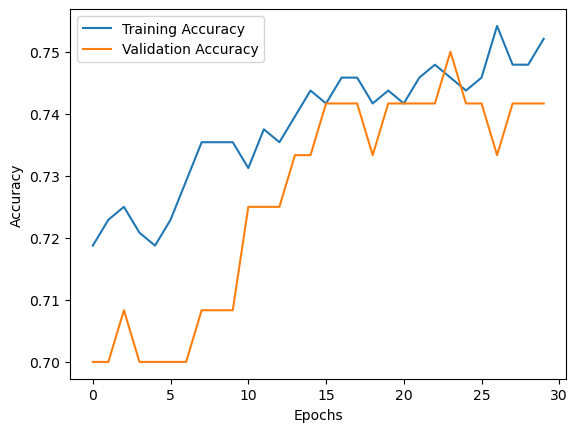

In [298]:
epochs = range(1, len(history.history['accuracy']) + 1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 7-13 | 세 모델 성능 평가 및 최종 모델 선택

### 문제
`logreg_model`, `dt_model`, `model` 세 모델을 검증 데이터로 평가하세요.

조건:
- 각 모델은 **학습할 때 사용한 전처리 형태와 동일한 형태의 검증 데이터**로 예측해야 합니다.
- 딥러닝 모델의 출력 확률은 `0.5`를 기준으로 `0` 또는 `1`로 변환하세요.
- 각 모델의 `Accuracy`와 `F1-score`를 계산하여 출력하세요.
- 최종 모델은 **F1-score가 가장 높은 모델**로 선택하세요.
- F1-score가 동일한 경우 **Accuracy가 더 높은 모델**을 선택하세요.
- 선택된 모델의 이름을 `best_model_name` 변수에 문자열로 저장하세요.

In [299]:
# 데이터 예측
logreg_pred = logreg_model.predict(X_valid_scaled)
dt_pred = dt_model.predict(X_valid_scaled) 
dl_prob = model.predict(X_valid_scaled)
dl_pred = (dl_prob >= 0.5).astype(int)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [300]:
# 라이브러리 임포트
from sklearn.metrics import accuracy_score, f1_score

In [301]:
# f1 score
logreg_f1_score = f1_score(y_valid, logreg_pred)
dt_f1_score = f1_score(y_valid, dt_pred)
dl_f1_score = f1_score(y_valid, dl_pred)

In [302]:
f1 = {'Logistic Regression' : logreg_f1_score, 'Decision Tree' : dt_f1_score, 'Deep Learning' :dl_f1_score}
best_model_name = max(f1, key = f1.get)

In [303]:
best_model_name

'Decision Tree'

## 7-14 | KMeans를 활용한 고객 세그먼트 분석

### 문제
정답 레이블을 사용하지 않고 고객을 3개의 그룹으로 군집화하세요.

조건:
- 군집화에 사용할 데이터에는 `Churn`을 포함하지 마세요.
- 원-핫 인코딩이 완료된 수치형 Feature를 사용하세요.
- Feature별 단위 차이의 영향을 줄인 뒤 군집화를 수행하세요.
- 클러스터 수: `3`
- `random_state=42`
- 군집 결과를 원본 `df`의 새 컬럼 `Cluster`에 저장하세요.
- `Cluster`별 `MonthlyCharges_USD`, `TotalUsage_GB`의 평균을 출력하세요.
- 출력 결과를 보고 각 군집의 특징을 간단히 해석해보세요.

In [304]:
from sklearn.cluster import KMeans

In [305]:
# 1. 정답 레이블 제외
X_cluster = df_encoded.drop(columns = 'Churn')
# 2. 스케일링
X_cluster_scaler = StandardScaler()
X_cluster_scaled = X_cluster_scaler.fit_transform(X_cluster)
# 3. kmeans
km = KMeans(
    n_clusters = 3, 
    random_state = 42
)
cluster = km.fit_predict(X_cluster_scaled)
# 4/ 군집 결괴 저장
df['Cluster'] = cluster
# 5. 군집별 평균 확인
df.groupby('Cluster')[['MonthlyCharges_USD', 'TotalUsage_GB']].mean()

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,MonthlyCharges_USD,TotalUsage_GB
Cluster,,
0,84.677049,245.557377
1,84.443795,234.866667
2,83.883416,260.155280
